In [46]:
# CELL 30: External validation - Logistic Regression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Model 1: Static RFM features
scores_static = cross_val_score(LogisticRegression(max_iter=1000), static_features, y_churn, cv=cv, scoring='roc_auc')
print(f"Static RFM features AUC: {scores_static.mean():.4f} (+/- {scores_static.std():.4f})")

# Model 2: Trajectory VAE embeddings
scores_traj_embed = cross_val_score(LogisticRegression(max_iter=1000), traj_features, y_churn, cv=cv, scoring='roc_auc')
print(f"Trajectory VAE embeddings AUC: {scores_traj_embed.mean():.4f} (+/- {scores_traj_embed.std():.4f})")

# Model 3: Trajectory VAE segment labels
scores_traj_label = cross_val_score(LogisticRegression(max_iter=1000), traj_labels_aligned.reshape(-1, 1), y_churn, cv=cv, scoring='roc_auc')
print(f"Trajectory VAE segment label AUC: {scores_traj_label.mean():.4f} (+/- {scores_traj_label.std():.4f})")

# Model 4: Static K-Means segment labels
static_labels_aligned = static_labels
scores_static_label = cross_val_score(LogisticRegression(max_iter=1000), static_labels_aligned.reshape(-1, 1), y_churn, cv=cv, scoring='roc_auc')
print(f"Static K-Means segment label AUC: {scores_static_label.mean():.4f} (+/- {scores_static_label.std():.4f})")

Static RFM features AUC: 0.6840 (+/- 0.0233)
Trajectory VAE embeddings AUC: 0.6805 (+/- 0.0262)
Trajectory VAE segment label AUC: 0.5959 (+/- 0.0226)
Static K-Means segment label AUC: 0.5390 (+/- 0.0353)


In [47]:
# CELL 31: External validation - LightGBM
import lightgbm as lgb
lgb_params = {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'random_state': SEED, 'verbose': -1}

# Model 1: Static RFM features
scores_static_lgb = cross_val_score(lgb.LGBMClassifier(**lgb_params), static_features, y_churn, cv=cv, scoring='roc_auc')
print(f"Static RFM + LightGBM AUC: {scores_static_lgb.mean():.4f} (+/- {scores_static_lgb.std():.4f})")

# Model 2: Trajectory VAE embeddings
scores_traj_lgb = cross_val_score(lgb.LGBMClassifier(**lgb_params), traj_features, y_churn, cv=cv, scoring='roc_auc')
print(f"Trajectory VAE + LightGBM AUC: {scores_traj_lgb.mean():.4f} (+/- {scores_traj_lgb.std():.4f})")

Static RFM + LightGBM AUC: 0.7769 (+/- 0.0182)
Trajectory VAE + LightGBM AUC: 0.7145 (+/- 0.0207)


In [48]:
# CELL 32: External validation summary
print("=" * 55)
print("EXTERNAL VALIDATION: Churn Prediction AUC")
print("=" * 55)
print(f"{'Features':<35} {'Logistic':<12} {'LightGBM':<12}")
print("-" * 55)
print(f"{'Static RFM':<35} {scores_static.mean():<12.4f} {scores_static_lgb.mean():<12.4f}")
print(f"{'Trajectory VAE embeddings':<35} {scores_traj_embed.mean():<12.4f} {scores_traj_lgb.mean():<12.4f}")
print(f"{'Trajectory VAE segment label':<35} {scores_traj_label.mean():<12.4f} {'-':<12}")
print(f"{'Static K-Means segment label':<35} {scores_static_label.mean():<12.4f} {'-':<12}")
print("=" * 55)

EXTERNAL VALIDATION: Churn Prediction AUC
Features                            Logistic     LightGBM    
-------------------------------------------------------
Static RFM                          0.6840       0.7769      
Trajectory VAE embeddings           0.6805       0.7145      
Trajectory VAE segment label        0.5959       -           
Static K-Means segment label        0.5390       -           


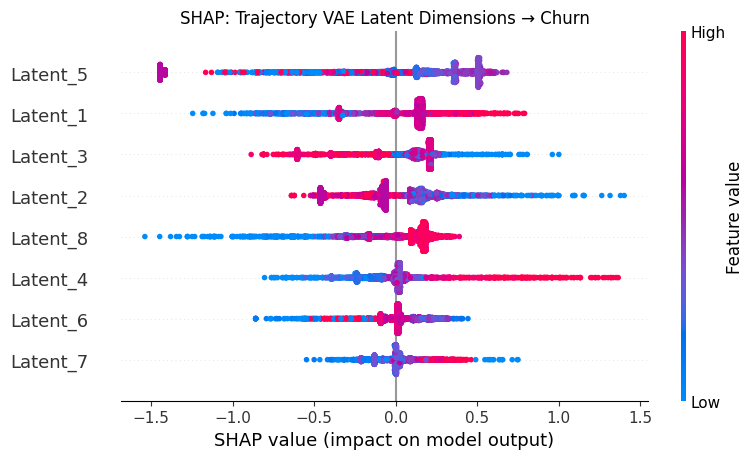

In [49]:
# CELL 33: SHAP Interpretability
# Train final LightGBM on trajectory embeddings
import shap
final_lgb = lgb.LGBMClassifier(**lgb_params)
final_lgb.fit(traj_features, y_churn)

# SHAP
explainer = shap.TreeExplainer(final_lgb)
shap_values = explainer.shap_values(traj_features)

# Feature naming: latent dimensions
latent_names = [f'Latent_{i+1}' for i in range(traj_features.shape[1])]

# Summary plot
shap.summary_plot(shap_values, traj_features, feature_names=latent_names, show=False)
plt.title('SHAP: Trajectory VAE Latent Dimensions → Churn')
plt.tight_layout()
plt.show()

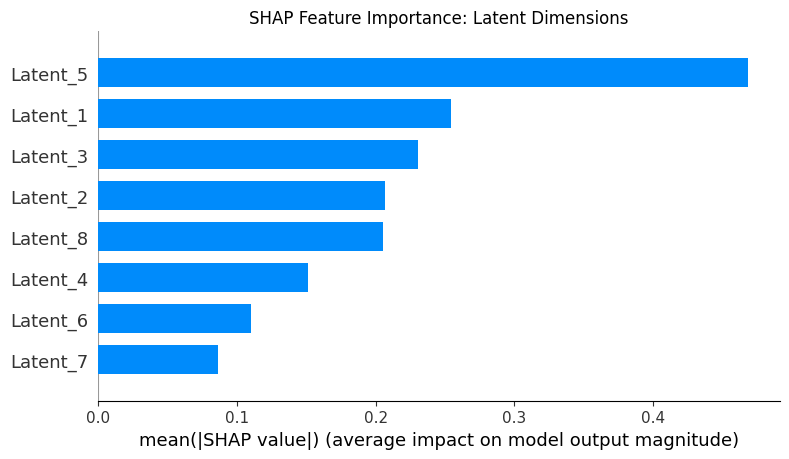

In [50]:
# CELL 34: SHAP feature importance bar
shap.summary_plot(shap_values, traj_features, feature_names=latent_names, plot_type='bar', show=False)
plt.title('SHAP Feature Importance: Latent Dimensions')
plt.tight_layout()
plt.show()

In [51]:
# CELL 35 (fixed): Segment Transition Analysis
train_df_q = train_df.copy()
train_df_q['quarter'] = train_df_q['InvoiceDate'].dt.to_period('Q')

quarters_sorted = sorted(train_df_q['quarter'].unique())
print(f"Quarters in training: {quarters_sorted}")

if len(quarters_sorted) >= 2:
    q1_ids = set(train_df_q[train_df_q['quarter'] == quarters_sorted[0]]['Customer ID'].astype(str))
    q2_ids = set(train_df_q[train_df_q['quarter'] == quarters_sorted[1]]['Customer ID'].astype(str))
    both_ids = list(q1_ids & q2_ids & set(customer_ids))
    print(f"Customers active in both {quarters_sorted[0]} and {quarters_sorted[1]}: {len(both_ids)}")
    
    # Map to indices
    q1_idx = [customer_ids.index(c) for c in both_ids]
    q2_idx = [customer_ids.index(c) for c in both_ids]
    
    q1_labels = trajectory_labels[q1_idx]
    q2_labels = trajectory_labels[q2_idx]
    
    n_clusters = optimal_k
    trans_matrix = np.zeros((n_clusters, n_clusters))
    for l1, l2 in zip(q1_labels, q2_labels):
        trans_matrix[l1, l2] += 1
    trans_matrix = trans_matrix / trans_matrix.sum(axis=1, keepdims=True)
    
    print("\nQuarter-to-Quarter Transition Matrix:")
    print(pd.DataFrame(trans_matrix.round(3), 
                        index=[f'From_C{i}' for i in range(n_clusters)],
                        columns=[f'To_C{i}' for i in range(n_clusters)]))
else:
    print("Not enough quarters for transition analysis.")

Quarters in training: [Period('2009Q4', 'Q-DEC'), Period('2010Q1', 'Q-DEC'), Period('2010Q2', 'Q-DEC'), Period('2010Q3', 'Q-DEC'), Period('2010Q4', 'Q-DEC'), Period('2011Q1', 'Q-DEC'), Period('2011Q2', 'Q-DEC'), Period('2011Q3', 'Q-DEC')]
Customers active in both 2009Q4 and 2010Q1: 584

Quarter-to-Quarter Transition Matrix:
          To_C0  To_C1  To_C2  To_C3  To_C4  To_C5  To_C6  To_C7  To_C8  \
From_C0     1.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
From_C1     NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
From_C2     0.0    0.0    1.0    0.0    0.0    0.0    0.0    0.0    0.0   
From_C3     0.0    0.0    0.0    1.0    0.0    0.0    0.0    0.0    0.0   
From_C4     NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
From_C5     NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
From_C6     0.0    0.0    0.0    0.0    0.0    0.0    1.0    0.0    0.0   
From_C7     0.0    0.0    0.0    0.0    0.0    0.0    0.0    1.0    0.0   

Surrogate fidelity (accuracy): 52.49%


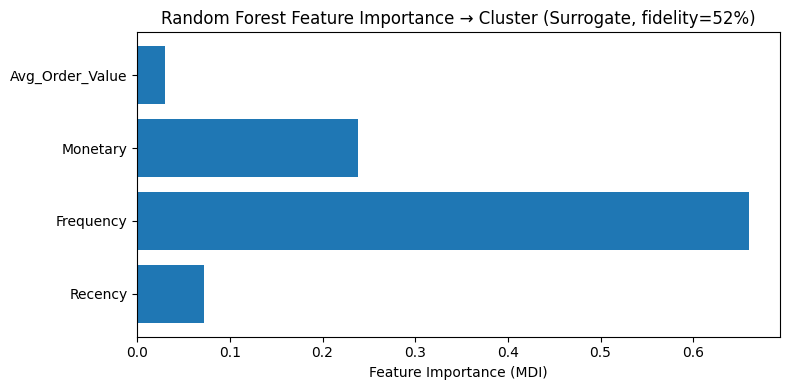


Per-Cluster Static RFM Means:
         Recency  Frequency  Monetary  Avg_Order_Value
Cluster                                               
0          -0.09      -0.14     -0.11            -0.07
1           0.01      -0.34     -0.17            -0.07
2          -0.59       1.16      0.43             0.10
3          -0.19       3.31      2.25             1.78
4          -0.58       0.02     -0.05            -0.06
5          -0.31      -0.11     -0.13            -0.12
6           0.56      -0.15     -0.13            -0.13
7           0.26      15.72      8.44            -0.09
8          -0.05       0.20      0.06             0.26
9           0.73      -0.37     -0.20            -0.17
10          0.25      -0.49     -0.22            -0.12
11          0.08      -0.00     -0.06            -0.11
12          3.47      -0.29      1.69             7.08
13         -0.12       0.38      0.04            -0.04
14         -0.90       6.64     21.12             4.57


In [52]:
# CELL 36 (fixed v3): Global SHAP only
from sklearn.ensemble import RandomForestClassifier

surrogate = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=SEED)
surrogate.fit(static_features, traj_labels_aligned)

surrogate_acc = surrogate.score(static_features, traj_labels_aligned)
print(f"Surrogate fidelity (accuracy): {surrogate_acc:.2%}")

# Use KernelExplainer or just report aggregate feature importance from RandomForest
importances = surrogate.feature_importances_
static_feature_names = ['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value']

plt.figure(figsize=(8, 4))
plt.barh(static_feature_names, importances)
plt.xlabel('Feature Importance (MDI)')
plt.title(f'Random Forest Feature Importance → Cluster (Surrogate, fidelity={surrogate_acc:.0%})')
plt.tight_layout()
plt.show()

# Per-cluster interpretation via mean feature values
print("\nPer-Cluster Static RFM Means:")
cluster_means = pd.DataFrame(static_features, columns=static_feature_names)
cluster_means['Cluster'] = traj_labels_aligned
print(cluster_means.groupby('Cluster').mean().round(2))

In [60]:
# CELL 44: Ablation - Static VAE embeddings vs Trajectory VAE embeddings
scores_static_vae_embed = cross_val_score(LogisticRegression(max_iter=1000), 
                                           static_embeddings, 
                                           y_churn, cv=cv, scoring='roc_auc')
print(f"Static VAE embeddings AUC: {scores_static_vae_embed.mean():.4f} (+/- {scores_static_vae_embed.std():.4f})")
print(f"Trajectory VAE embeddings AUC: {scores_traj_embed.mean():.4f} (+/- {scores_traj_embed.std():.4f})")
print(f"Delta: {(scores_traj_embed.mean() - scores_static_vae_embed.mean())*100:.1f} percentage points")

Static VAE embeddings AUC: 0.6903 (+/- 0.0246)
Trajectory VAE embeddings AUC: 0.6805 (+/- 0.0262)
Delta: -1.0 percentage points


In [62]:
# CELL 46: LaTeX table generation for paper
print("\n% ========== LATEX TABLE: INTERNAL METRICS ==========")
print("\\begin{table}[h]")
print("\\caption{Internal clustering metrics (k=5)}")
print("\\label{tab:internal}")
print("\\begin{tabular}{lcc}")
print("\\hline")
print("Method & Silhouette & Davies-Bouldin \\\\")
print("\\hline")
print(f"Trajectory VAE + GMM & {sil_k5:.4f} & {db_k5:.4f} \\\\")
print(f"Static K-Means & {static_sil_k5:.4f} & {static_db_k5:.4f} \\\\")
print(f"Static VAE + K-Means & {static_vae_sil_k5:.4f} & {static_vae_db_k5:.4f} \\\\")
print("\\hline")
print("\\end{tabular}")
print("\\end{table}")

print("\n% ========== LATEX TABLE: EXTERNAL VALIDATION ==========")
print("\\begin{table}[h]")
print("\\caption{External validation: Churn prediction AUC (5-fold CV)}")
print("\\label{tab:external}")
print("\\begin{tabular}{lcc}")
print("\\hline")
print("Features & Logistic & LightGBM \\\\")
print("\\hline")
print(f"Static RFM & {scores_static.mean():.4f} & {scores_static_lgb.mean():.4f} \\\\")
print(f"Static VAE embeddings & {scores_static_vae_embed.mean():.4f} & - \\\\")
print(f"Trajectory VAE embeddings & {scores_traj_embed.mean():.4f} & {scores_traj_lgb.mean():.4f} \\\\")
print(f"Trajectory segment label & {scores_traj_label_k5.mean():.4f} & - \\\\")
print(f"Static K-Means label & {scores_static_label_k5.mean():.4f} & - \\\\")
print("\\hline")
print("\\end{tabular}")
print("\\end{table}")

print("\n% ========== LATEX TABLE: FEATURE IMPORTANCE ==========")
print("\\begin{table}[h]")
print("\\caption{Surrogate model feature importance (RandomForest, fidelity=" + f"{surrogate_acc_k5:.1%}" + ")}")
print("\\label{tab:features}")
print("\\begin{tabular}{lc}")
print("\\hline")
print("Feature & MDI Importance \\\\")
print("\\hline")
for name, imp in zip(static_feature_names, importances_k5):
    print(f"{name} & {imp:.4f} \\\\")
print("\\hline")
print("\\end{tabular}")
print("\\end{table}")


% ========== LATEX TABLE: INTERNAL METRICS ==========
\begin{table}[h]
\caption{Internal clustering metrics (k=5)}
\label{tab:internal}
\begin{tabular}{lcc}
\hline
Method & Silhouette & Davies-Bouldin \\
\hline
Trajectory VAE + GMM & 0.1482 & 2.0371 \\
Static K-Means & 0.5457 & 0.7586 \\
Static VAE + K-Means & 0.5598 & 0.7611 \\
\hline
\end{tabular}
\end{table}

% ========== LATEX TABLE: EXTERNAL VALIDATION ==========
\begin{table}[h]
\caption{External validation: Churn prediction AUC (5-fold CV)}
\label{tab:external}
\begin{tabular}{lcc}
\hline
Features & Logistic & LightGBM \\
\hline
Static RFM & 0.6840 & 0.7769 \\
Static VAE embeddings & 0.6903 & - \\
Trajectory VAE embeddings & 0.6805 & 0.7145 \\
Trajectory segment label & 0.5609 & - \\
Static K-Means label & 0.5891 & - \\
\hline
\end{tabular}
\end{table}

% ========== LATEX TABLE: FEATURE IMPORTANCE ==========
\begin{table}[h]
\caption{Surrogate model feature importance (RandomForest, fidelity=62.8%)}
\label{tab:features}
\begin{